In [1]:
from google.colab import drive
import pandas as pd

# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Definir la ruta exacta según tu imagen
ruta = '/content/drive/MyDrive/Proyecto_Diabetes/diabetes_prediction_dataset.csv'

# 3. Cargar el dataset en un DataFrame de pandas
df = pd.read_csv(ruta)

# 4. Inspección inicial del estado de los datos
print("Primeros registros del dataset:")
print(df.head())
print("\nInformación general de las columnas:")
df.info()

Mounted at /content/drive
Primeros registros del dataset:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

Información general de las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               ---

In [2]:
# Verificar duplicados y nulos
print(f"Datos duplicados: {df.duplicated().sum()}")
print(f"Datos nulos:\n{df.isnull().sum()}")

# Eliminar duplicados si existen (como parte de la limpieza)
df = df.drop_duplicates()
print(f"\nTamaño del dataset después de eliminar duplicados: {df.shape}")

Datos duplicados: 3854
Datos nulos:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Tamaño del dataset después de eliminar duplicados: (96146, 9)


In [3]:
# Convertir categorías a números (Label Encoding)
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()
smoking_encoder = LabelEncoder()

df = df.copy()

df["gender"] = gender_encoder.fit_transform(df["gender"])
df["smoking_history"] = smoking_encoder.fit_transform(
    df["smoking_history"]
)

print("Codificación de gender:")
print(dict(zip(
    gender_encoder.classes_,
    gender_encoder.transform(gender_encoder.classes_)
)))

print("\nCodificación de smoking_history:")
print(dict(zip(
    smoking_encoder.classes_,
    smoking_encoder.transform(smoking_encoder.classes_)
)))

Codificación de gender:
{'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}

Codificación de smoking_history:
{'No Info': np.int64(0), 'current': np.int64(1), 'ever': np.int64(2), 'former': np.int64(3), 'never': np.int64(4), 'not current': np.int64(5)}


**EXPLORACION INICIAL**

Importancia exploratoria de características:
HbA1c_level            0.3959
blood_glucose_level    0.3188
bmi                    0.1238
age                    0.1026
smoking_history        0.0277
hypertension           0.0156
heart_disease          0.0093
gender                 0.0062
dtype: float64

Esta estimación permite observar patrones preliminares del dataset.
La importancia de una característica no demuestra causalidad clínica ni reemplaza una validación externa.


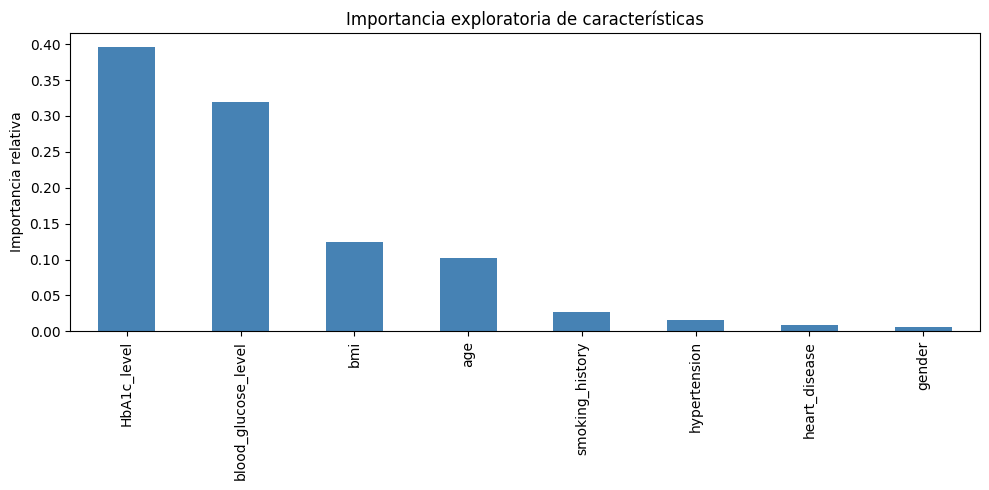

In [4]:
# ── EXPLORACIÓN INICIAL: Importancia de Características ──────────────────────
# Se entrena un modelo base provisional SOLO para identificar qué atributos
# tienen mayor poder predictivo antes de aplicar cualquier transformación.
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

X_explore = df.drop(columns=['diabetes'])
y_explore = df['diabetes']

# Escalado temporal solo para la exploración
scaler_explore = StandardScaler()
X_explore_scaled = scaler_explore.fit_transform(X_explore)

rf_explore = RandomForestClassifier(n_estimators=100, random_state=42)
rf_explore.fit(X_explore_scaled, y_explore)

importances_explore = pd.Series(
    rf_explore.feature_importances_,
    index=X_explore.columns
).sort_values(ascending=False)

print("Importancia exploratoria de características:")
print(importances_explore.round(4))
print("\nEsta estimación permite observar patrones preliminares del dataset.")
print("La importancia de una característica no demuestra causalidad clínica ni reemplaza una validación externa.")

plt.figure(figsize=(10, 5))
importances_explore.plot(kind='bar', color='steelblue')
plt.title("Importancia exploratoria de características")
plt.ylabel("Importancia relativa")
plt.tight_layout()
plt.show()

**DISTRIBUCIÓN DE CLASES ORIGINAL**


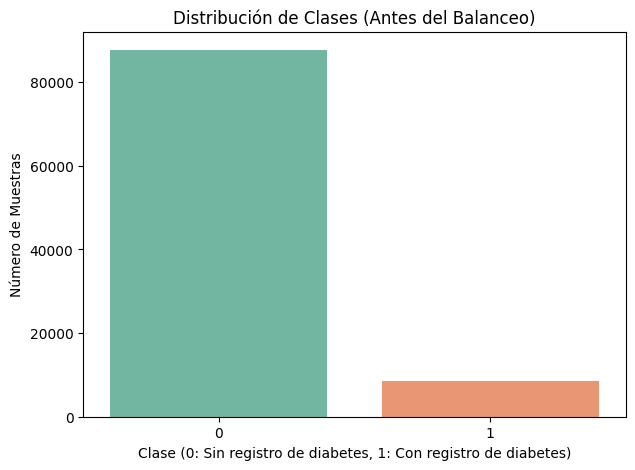

Cantidad de muestras por clase:
diabetes
0    87664
1     8482
Name: count, dtype: int64

Desbalance: 10.3x más registros de clase negativa que de clase positiva


In [5]:
# ── DISTRIBUCIÓN DE CLASES ANTES DEL BALANCEO ────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.countplot(x='diabetes', data=df, hue='diabetes', palette='Set2', legend=False)
plt.title("Distribución de Clases (Antes del Balanceo)")
plt.xlabel("Clase (0: Sin registro de diabetes, 1: Con registro de diabetes)")
plt.ylabel("Número de Muestras")
plt.show()

print("Cantidad de muestras por clase:")
print(df['diabetes'].value_counts())
print(f"\nDesbalance: {df['diabetes'].value_counts()[0] / df['diabetes'].value_counts()[1]:.1f}x más registros de clase negativa que de clase positiva")

**MATRIZ DE CORRELACIÓN**


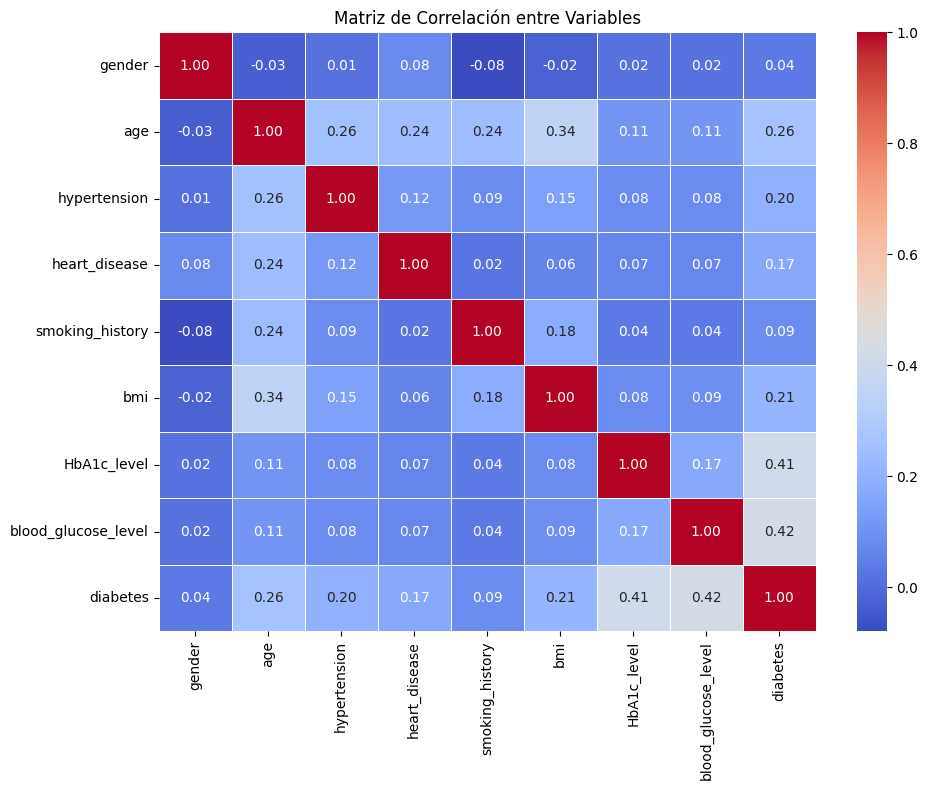

In [6]:
# ── MATRIZ DE CORRELACIÓN ENTRE VARIABLES ────────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación entre Variables")
plt.tight_layout()
plt.show()

Las correlaciones correspondientes a `gender` y `smoking_history`
deben interpretarse con cautela. Estas variables fueron codificadas
numéricamente para su procesamiento, pero sus códigos representan
categorías y no una escala ordinal o una relación de magnitud.

***TRATAMIENTO DE OUTLINERS (IQR)**

In [7]:
# ── TRATAMIENTO DE OUTLIERS MEDIANTE IQR ─────────────────────────────────────
# Se analizan los valores extremos de las variables numéricas continuas
# calculando los límites definidos por el Rango Intercuartílico.

import numpy as np

df_out = df.copy()

# Solo se aplica IQR a variables numéricas continuas con posibles outliers
columnas_iqr = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

for col in columnas_iqr:
    Q1 = df_out[col].quantile(0.25)
    Q3 = df_out[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_lim = Q1 - 1.5 * IQR
    upper_lim = Q3 + 1.5 * IQR
    antes = ((df_out[col] < lower_lim) | (df_out[col] > upper_lim)).sum()
    print(f"  {col}: {antes} posibles outliers identificados → rango [{lower_lim:.2f}, {upper_lim:.2f}]")

# Los valores extremos se identifican únicamente con fines exploratorios.
# El dataset utilizado para el entrenamiento no se recorta ni se modifica.

print("\n(El dataset original no se modificó)")

  age: 0 posibles outliers identificados → rango [-28.50, 111.50]
  bmi: 5354 posibles outliers identificados → rango [13.71, 39.55]
  HbA1c_level: 1312 posibles outliers identificados → rango [2.70, 8.30]
  blood_glucose_level: 2031 posibles outliers identificados → rango [11.50, 247.50]

(El dataset original no se modificó)


In [8]:
# Instalar imbalanced-learn si no está instalado
!pip install imbalanced-learn

import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTENC

X = df.drop(columns=["diabetes"])
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train_original = X_train.copy()
y_train_original = y_train.copy()

print("Distribución del entrenamiento original:")
print(y_train_original.value_counts().sort_index())
print(f"Total: {len(y_train_original)}")

categorical_indices = [
    X_train.columns.get_loc("gender"),
    X_train.columns.get_loc("hypertension"),
    X_train.columns.get_loc("heart_disease"),
    X_train.columns.get_loc("smoking_history")
]

smote_nc = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)

X_train_resampled, y_train_resampled = smote_nc.fit_resample(
    X_train,
    y_train
)

X_train = pd.DataFrame(
    X_train_resampled,
    columns=X_train.columns
)

y_train = pd.Series(
    y_train_resampled,
    name=y_train.name
)

print("\nDistribución del entrenamiento después de SMOTENC:")
print(y_train.value_counts().sort_index())
print(f"Total: {len(y_train)}")


Distribución del entrenamiento original:
diabetes
0    70130
1     6786
Name: count, dtype: int64
Total: 76916

Distribución del entrenamiento después de SMOTENC:
diabetes
0    70130
1    70130
Name: count, dtype: int64
Total: 140260


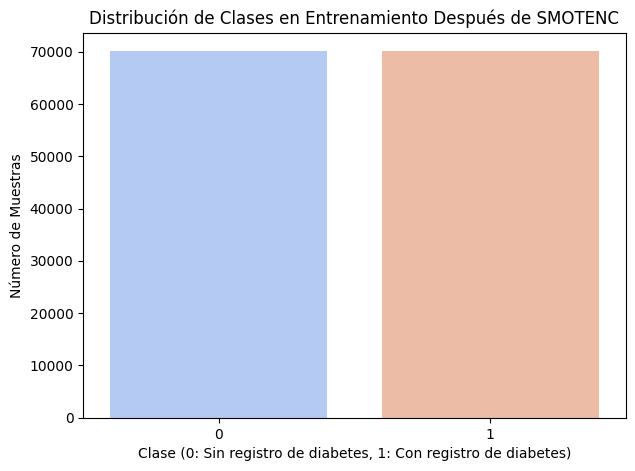

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.countplot(
    x=y_train, hue=y_train, palette='coolwarm', legend=False
)
plt.title("Distribución de Clases en Entrenamiento Después de SMOTENC")
plt.xlabel("Clase (0: Sin registro de diabetes, 1: Con registro de diabetes)")
plt.ylabel("Número de Muestras")
plt.show()

Después de separar los conjuntos de entrenamiento y prueba, se aplicó
SMOTENC exclusivamente al conjunto de entrenamiento. Esta técnica
permite balancear la clase minoritaria considerando las variables
categóricas y binarias del dataset. El conjunto de prueba conserva su
distribución original y permanece aislado para la evaluación final.

Tamaño del conjunto de entrenamiento: (140260, 8)
Distribución en entrenamiento: Counter({0: 70130, 1: 70130})


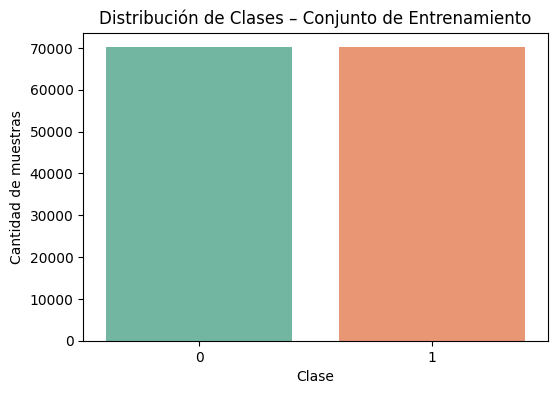

In [10]:
#3.3 DATA SET ENTRENAMIENTO
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Distribución en entrenamiento:", Counter(y_train))

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, hue=y_train, palette='Set2', legend=False)
plt.title("Distribución de Clases – Conjunto de Entrenamiento")
plt.xlabel("Clase")
plt.ylabel("Cantidad de muestras")
plt.show()

Tamaño del conjunto de prueba: (19230, 8)
Distribución en prueba: Counter({0: 17534, 1: 1696})


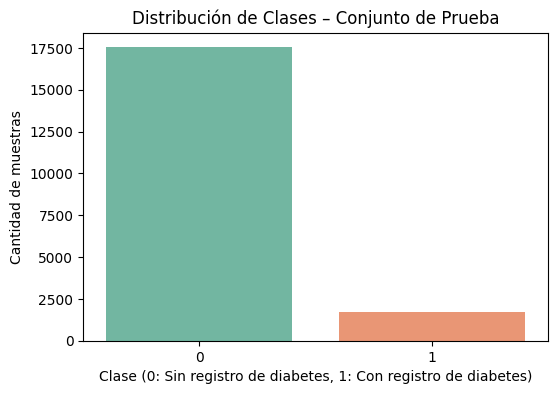

In [11]:
# ── VISUALIZACIÓN DE DISTRIBUCIÓN: TRAINING Y TEST ───────────────────────────
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

print("Tamaño del conjunto de prueba:", X_test.shape)
print("Distribución en prueba:", Counter(y_test))

plt.figure(figsize=(6, 4))
sns.countplot(x=y_test, hue=y_test, palette='Set2', legend=False)
plt.title("Distribución de Clases – Conjunto de Prueba")
plt.xlabel("Clase (0: Sin registro de diabetes, 1: Con registro de diabetes)")
plt.ylabel("Cantidad de muestras")
plt.show()

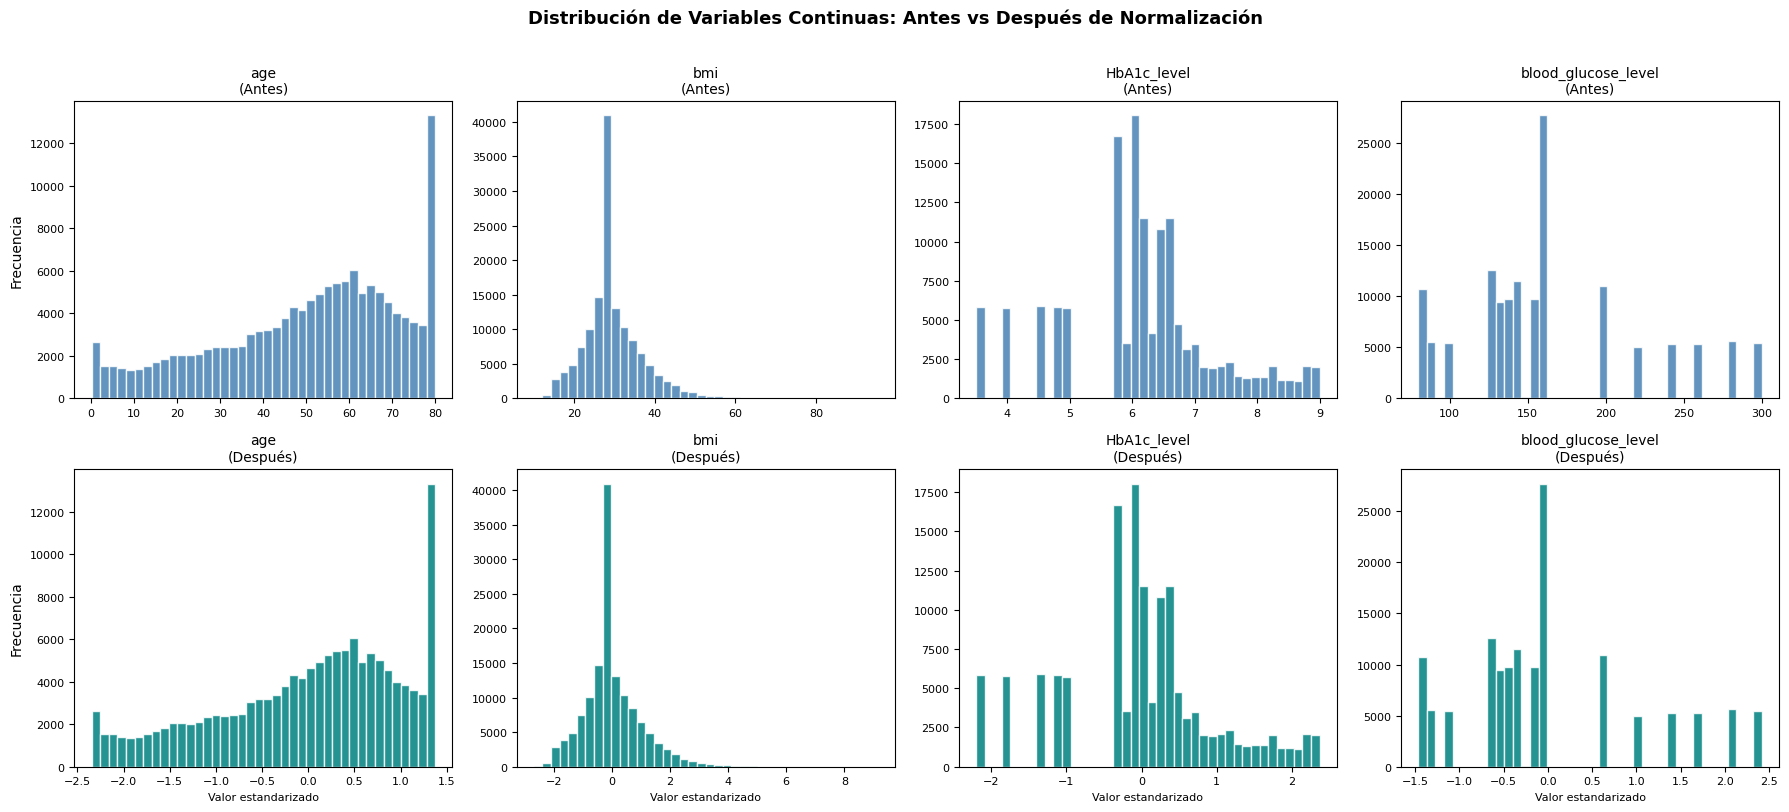


── RESUMEN ESTADÍSTICO ──────────────────────────────────────────────────

ANTES de normalizar:
             age        bmi  HbA1c_level  blood_glucose_level
count  140260.00  140260.00    140260.00            140260.00
mean       50.49      29.35         6.15               163.04
std        21.49       7.21         1.20                56.65
min         0.08      10.01         3.50                80.00
25%        36.00      25.83         5.70               130.00
50%        54.23      27.39         6.19               155.00
75%        67.13      32.68         6.66               200.00
max        80.00      95.22         9.00               300.00

DESPUÉS de normalizar:
             age        bmi  HbA1c_level  blood_glucose_level
count  140260.00  140260.00    140260.00            140260.00
mean        0.00      -0.00        -0.00                 0.00
std         1.00       1.00         1.00                 1.00
min        -2.35      -2.68        -2.20                -1.47
25%        

In [12]:
# ── 3.2 VISUALIZACIÓN COMPARATIVA: ANTES VS DESPUÉS DE NORMALIZACIÓN ──────────────
# Solo se grafican las variables numéricas continuas (excluye binarias 0/1)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

# Variables continuas con distribución real (no binarias)
vars_continuas = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# Escalar X_train para obtener X_train_scaled
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_train_df       = pd.DataFrame(X_train,        columns=X.columns)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Distribución de Variables Continuas: Antes vs Después de Normalización",
             fontsize=13, fontweight='bold', y=1.01)

for i, col in enumerate(vars_continuas):
    # Fila 0: ANTES
    axes[0, i].hist(X_train_df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col}\n(Antes)', fontsize=10)
    axes[0, i].set_ylabel("Frecuencia" if i == 0 else "")
    axes[0, i].tick_params(labelsize=8)

    # Fila 1: DESPUÉS
    axes[1, i].hist(X_train_scaled_df[col], bins=40, color='teal', edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'{col}\n(Después)', fontsize=10)
    axes[1, i].set_ylabel("Frecuencia" if i == 0 else "")
    axes[1, i].set_xlabel("Valor estandarizado", fontsize=8)
    axes[1, i].tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('normalizacion_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen de estadísticas antes y después
print("\n── RESUMEN ESTADÍSTICO ──────────────────────────────────────────────────")
print("\nANTES de normalizar:")
print(X_train_df[vars_continuas].describe().round(2))
print("\nDESPUÉS de normalizar:")
print(X_train_scaled_df[vars_continuas].describe().round(2))

In [13]:
#3.3.3 SET DE VALIDACION POR CROSS-VALIDATION
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Validación cruzada configurada:")
print(f"  Tipo         : Stratified K-Fold")
print(f"  Particiones  : K = 5")
print(f"  Shuffle      : activado (random_state=42)")
print(f"\nEsta configuración se aplicará durante la fase de entrenamiento (Sección 4).")

Validación cruzada configurada:
  Tipo         : Stratified K-Fold
  Particiones  : K = 5
  Shuffle      : activado (random_state=42)

Esta configuración se aplicará durante la fase de entrenamiento (Sección 4).


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

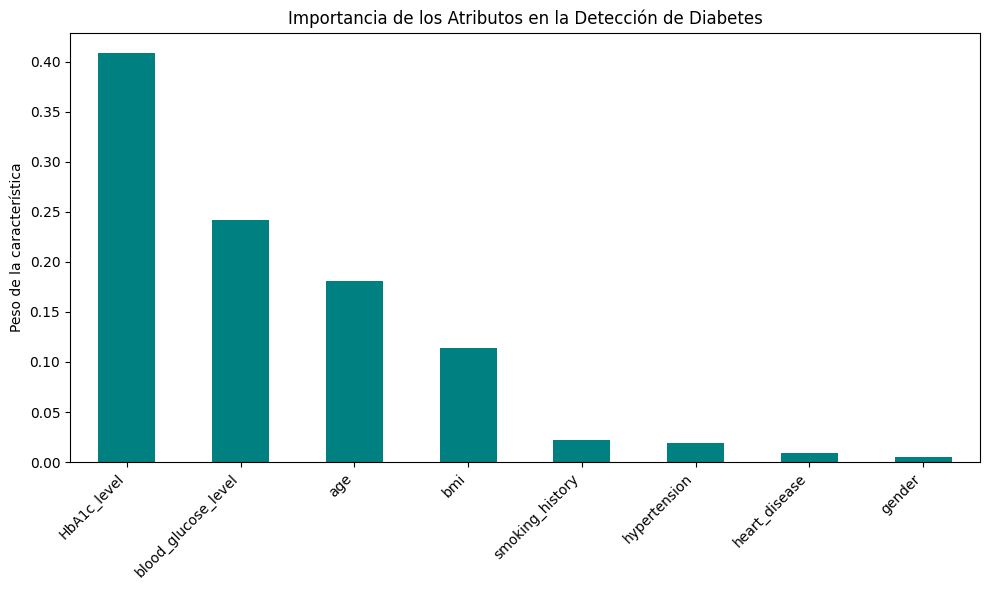

In [15]:
# ── IMPORTANCIA FINAL DE ATRIBUTOS ────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='teal')
plt.title("Importancia de los Atributos en la Detección de Diabetes")
plt.ylabel("Peso de la característica")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Aprendizaje


In [16]:

# Importación de las librerías de los modelos seleccionados
from sklearn.ensemble import RandomForestClassifier

# 1. Inicialización del modelo Random Forest
# Se renombra a rf_comparison_model para no sobrescribir el final.
rf_comparison_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)


##4.1 PLANTEAMIENTO DEL MODELO DE APRENDIZAJE

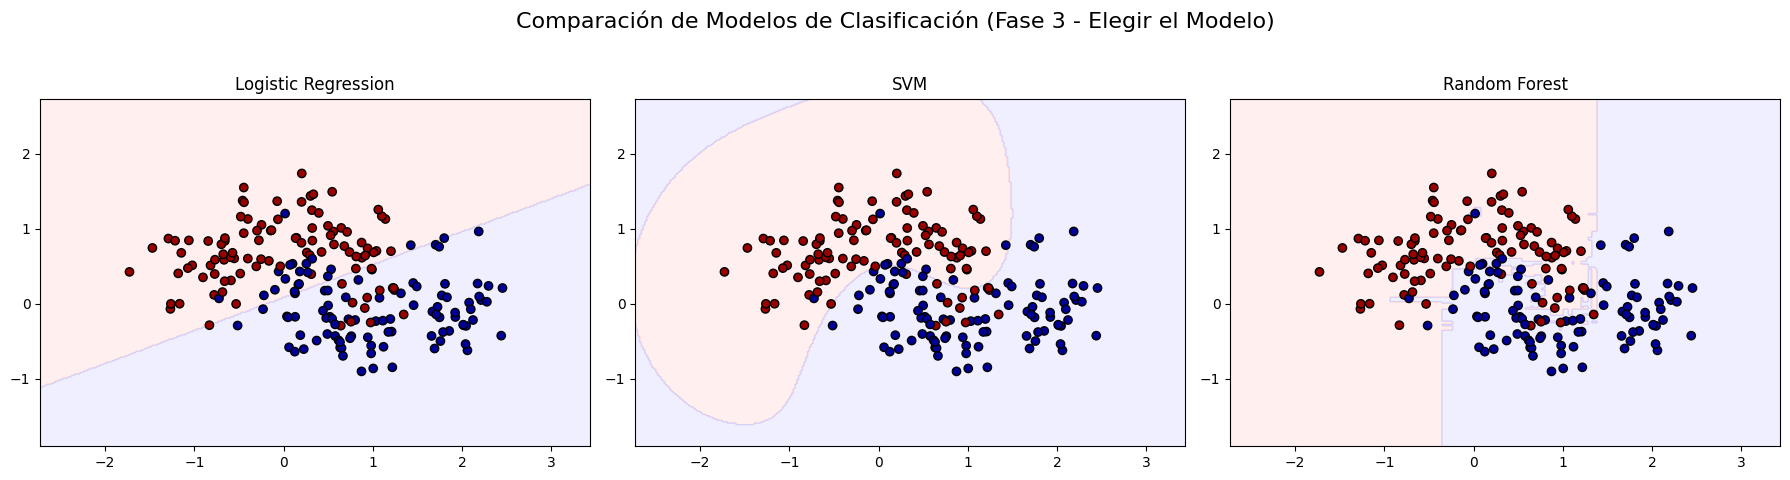

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# 1. Generar datos simulados no lineales (estilo el informe de referencia)
X_sim, y_sim = make_moons(n_samples=200, noise=0.3, random_state=42)

# 2. Definir los modelos a comparar
models = [
    ("Logistic Regression", LogisticRegression()),
    ("SVM", SVC(kernel='rbf', C=1)),
    ("Random Forest", RandomForestClassifier(n_estimators=10, random_state=42))
]

# 3. Configurar la visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparación de Modelos de Clasificación (Fase 3 - Elegir el Modelo)', fontsize=16)

x_min, x_max = X_sim[:, 0].min() - 1, X_sim[:, 0].max() + 1
y_min, y_max = X_sim[:, 1].min() - 1, X_sim[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

for i, (name, model) in enumerate(models):
    model.fit(X_sim, y_sim)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axes[i].contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFCCCC', '#CCCCFF']))
    axes[i].scatter(X_sim[:, 0], X_sim[:, 1], c=y_sim, edgecolors='k', cmap=ListedColormap(['#990000', '#000099']))
    axes[i].set_title(name)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##4.2 DESARROLLO E IMPLEMENTACION DEL MODELO

In [18]:
# El modelo ya definido con anterioridad y listo para su entrenamiento
rf_model

RandomForestClassifier(n_jobs=-1, random_state=42)

##V. Comprobacion

In [19]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
import numpy as np

categorical_indices_cv = [
    X_train_original.columns.get_loc("gender"),
    X_train_original.columns.get_loc("hypertension"),
    X_train_original.columns.get_loc("heart_disease"),
    X_train_original.columns.get_loc("smoking_history")
]

rf_cv_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

cv_pipeline = ImbPipeline(steps=[
    (
        "smotenc",
        SMOTENC(
            categorical_features=categorical_indices_cv,
            random_state=42
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        rf_cv_model
    )
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    cv_pipeline,
    X_train_original,
    y_train_original,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print("Resultados de Validación Cruzada (promedio ± desviación estándar):\n")
for metric in scoring:
    mean = cv_results[f"test_{metric}"].mean()
    std = cv_results[f"test_{metric}"].std()
    print(f"{metric:>9}: {mean:.3f} ± {std:.3f}")

# SMOTENC se ejecuta dentro de cada fold y solamente sobre la porción
# de entrenamiento interno. La porción de validación de cada fold
# conserva su distribución original.

Resultados de Validación Cruzada (promedio ± desviación estándar):

 accuracy: 0.955 ± 0.001
precision: 0.749 ± 0.006
   recall: 0.745 ± 0.011
       f1: 0.747 ± 0.008
  roc_auc: 0.965 ± 0.003


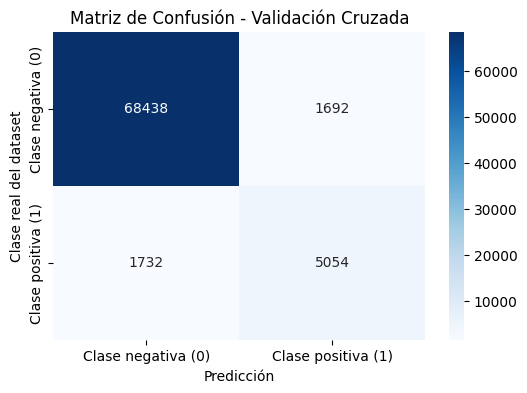


Reporte de clasificación (Validación):
                    precision    recall  f1-score   support

Clase negativa (0)       0.98      0.98      0.98     70130
Clase positiva (1)       0.75      0.74      0.75      6786

          accuracy                           0.96     76916
         macro avg       0.86      0.86      0.86     76916
      weighted avg       0.96      0.96      0.96     76916



In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_cv_pred = cross_val_predict(
    cv_pipeline,
    X_train_original,
    y_train_original,
    cv=cv,
    method="predict",
    n_jobs=-1
)

cm_cv = confusion_matrix(y_train_original, y_cv_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_cv, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Clase negativa (0)", "Clase positiva (1)"],
            yticklabels=["Clase negativa (0)", "Clase positiva (1)"])
plt.title("Matriz de Confusión - Validación Cruzada")
plt.xlabel("Predicción")
plt.ylabel("Clase real del dataset")
plt.show()

print("\nReporte de clasificación (Validación):")
print(classification_report(y_train_original, y_cv_pred, target_names=["Clase negativa (0)", "Clase positiva (1)"]))

In [21]:
train_acc_mean = cv_results["train_accuracy"].mean()
val_acc_mean = cv_results["test_accuracy"].mean()

print(f"\nAccuracy en TRAIN (CV): {train_acc_mean:.3f}")
print(f"Accuracy en VALID (CV): {val_acc_mean:.3f}")

diff = abs(train_acc_mean - val_acc_mean)
print(f"\nDiferencia Train-Validación: {diff:.3f}")

print(
    "\nAunque el modelo obtiene un rendimiento mayor en las particiones de "
    "entrenamiento, las métricas de validación cruzada y del conjunto de prueba "
    "independiente permiten evaluar su capacidad de generalización. La diferencia "
    "entre entrenamiento y validación debe reconocerse y analizarse sin afirmar "
    "que el sobreajuste está completamente descartado."
)

if val_acc_mean > 0.94:
    print(
        f"\nNota: Las métricas de validación ({val_acc_mean:.3f}) y de test son "
        "similares entre sí, lo que sugiere estabilidad en la generalización, "
        "aunque la diferencia con el accuracy de entrenamiento (0.999) indica "
        "un grado de ajuste a los datos de entrenamiento que no puede descartarse."
    )


Accuracy en TRAIN (CV): 0.999
Accuracy en VALID (CV): 0.955

Diferencia Train-Validación: 0.044

Aunque el modelo obtiene un rendimiento mayor en las particiones de entrenamiento, las métricas de validación cruzada y del conjunto de prueba independiente permiten evaluar su capacidad de generalización. La diferencia entre entrenamiento y validación debe reconocerse y analizarse sin afirmar que el sobreajuste está completamente descartado.

Nota: Las métricas de validación (0.955) y de test son similares entre sí, lo que sugiere estabilidad en la generalización, aunque la diferencia con el accuracy de entrenamiento (0.999) indica un grado de ajuste a los datos de entrenamiento que no puede descartarse.


##Seccion 06: Evaluacion

## VI. Evaluación Final

A partir de esta sección se construye el pipeline definitivo del
proyecto:

`SMOTENC → StandardScaler → RandomForestClassifier`

Los resultados producidos previamente mediante `rf_model`,
`X_train_scaled` y `X_test_scaled` se conservan como parte del análisis
preliminar y de la estructura original del notebook.

Para el informe, la exportación del modelo y el despliegue deben
utilizarse exclusivamente las métricas, la matriz de confusión, la
curva ROC y la importancia de atributos generadas por
`final_pipeline`.

El umbral de decisión se establece en 0.5 como criterio fijo del
proyecto. No se realiza calibración, optimización ni selección del
umbral utilizando el conjunto de prueba.

In [22]:
categorical_indices_final = [
    X_train_original.columns.get_loc("gender"),
    X_train_original.columns.get_loc("hypertension"),
    X_train_original.columns.get_loc("heart_disease"),
    X_train_original.columns.get_loc("smoking_history")
]

final_pipeline = ImbPipeline(steps=[
    (
        "smotenc",
        SMOTENC(
            categorical_features=categorical_indices_final,
            random_state=42
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=100,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        )
    )
])

final_pipeline.fit(
    X_train_original,
    y_train_original
)

print("Pipeline final entrenado con todo el conjunto de entrenamiento original.")

Pipeline final entrenado con todo el conjunto de entrenamiento original.


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

DECISION_THRESHOLD = 0.5

y_probs_final = final_pipeline.predict_proba(X_test)[:, 1]

y_pred_final = (
    y_probs_final >= DECISION_THRESHOLD
).astype(int)

accuracy_final = accuracy_score(
    y_test,
    y_pred_final
)

precision_final = precision_score(
    y_test,
    y_pred_final,
    zero_division=0
)

recall_final = recall_score(
    y_test,
    y_pred_final
)

f1_final = f1_score(
    y_test,
    y_pred_final
)

roc_auc_final = roc_auc_score(
    y_test,
    y_probs_final
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_final
).ravel()

specificity_final = tn / (tn + fp)
false_negative_rate_final = fn / (fn + tp)

print("EVALUACIÓN FINAL")
print(f"Umbral de decisión utilizado: {DECISION_THRESHOLD:.2f}")
print(f"Accuracy: {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall: {recall_final:.4f}")
print(f"F1-score: {f1_final:.4f}")
print(f"Especificidad: {specificity_final:.4f}")
print(
    f"Tasa de falsos negativos: "
    f"{false_negative_rate_final:.4f}"
)
print(f"ROC-AUC: {roc_auc_final:.4f}")
print("\nMatriz de confusión:")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")
print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=[
            "Clase negativa",
            "Clase positiva"
        ],
        zero_division=0
    )
)


EVALUACIÓN FINAL
Umbral de decisión utilizado: 0.50
Accuracy: 0.9548
Precision: 0.7404
Recall: 0.7500
F1-score: 0.7452
Especificidad: 0.9746
Tasa de falsos negativos: 0.2500
ROC-AUC: 0.9633

Matriz de confusión:
TN: 17088
FP: 446
FN: 424
TP: 1272

Reporte de clasificación:
                precision    recall  f1-score   support

Clase negativa       0.98      0.97      0.98     17534
Clase positiva       0.74      0.75      0.75      1696

      accuracy                           0.95     19230
     macro avg       0.86      0.86      0.86     19230
  weighted avg       0.96      0.95      0.95     19230



In [24]:
metrics_summary = pd.DataFrame([
    {
        "Métrica": "Accuracy",
        "Resultado": accuracy_final
    },
    {
        "Métrica": "Precision",
        "Resultado": precision_final
    },
    {
        "Métrica": "Recall",
        "Resultado": recall_final
    },
    {
        "Métrica": "F1-score",
        "Resultado": f1_final
    },
    {
        "Métrica": "Especificidad",
        "Resultado": specificity_final
    },
    {
        "Métrica": "Tasa de falsos negativos",
        "Resultado": false_negative_rate_final
    },
    {
        "Métrica": "ROC-AUC",
        "Resultado": roc_auc_final
    }
])

metrics_summary["Resultado"] = (
    metrics_summary["Resultado"].round(4)
)

metrics_summary

,Métrica,Resultado
0,Accuracy,0.9548
1,Precision,0.7404
2,Recall,0.7500
3,F1-score,0.7452
4,Especificidad,0.9746
5,Tasa de falsos negativos,0.2500
6,ROC-AUC,0.9633


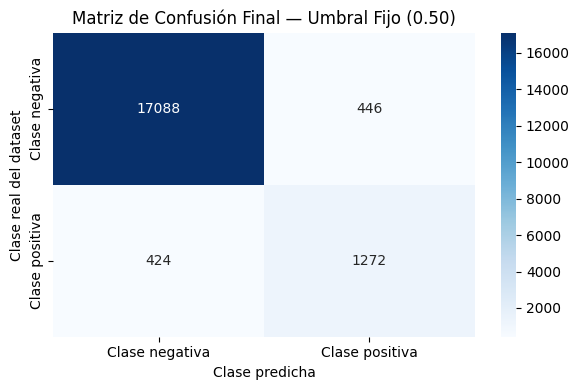

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Clase negativa", "Clase positiva"],
    yticklabels=["Clase negativa", "Clase positiva"]
)
plt.title(
    f"Matriz de Confusión Final — Umbral Fijo ({DECISION_THRESHOLD:.2f})"
)
plt.xlabel("Clase predicha")
plt.ylabel("Clase real del dataset")
plt.tight_layout()
plt.show()

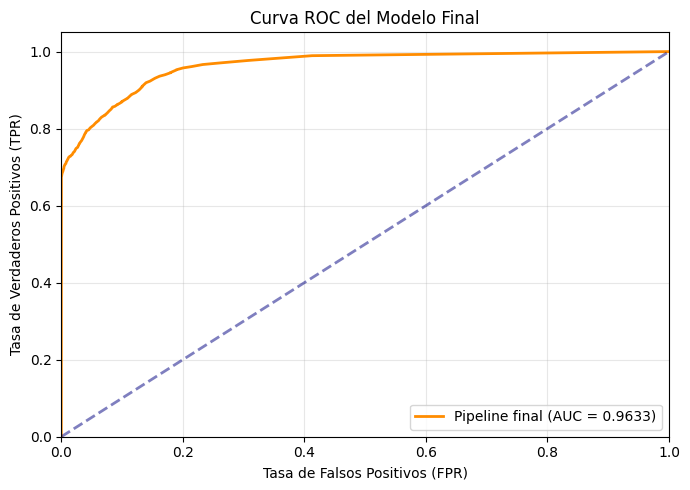

Área Bajo la Curva ROC (AUC): 0.9633


In [26]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_final, tpr_final, _ = roc_curve(
    y_test,
    y_probs_final
)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr_final,
    tpr_final,
    color="darkorange",
    lw=2,
    label=f"Pipeline final (AUC = {roc_auc_final:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=2,
    linestyle="--",
    alpha=0.5
)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC del Modelo Final")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Área Bajo la Curva ROC (AUC): {roc_auc_final:.4f}")

Calculo de la importancia final

In [27]:
final_model = final_pipeline.named_steps["model"]

final_importances = pd.Series(
    final_model.feature_importances_,
    index=X_train_original.columns
).sort_values(ascending=False)

print(final_importances)

HbA1c_level            0.408231
blood_glucose_level    0.241750
age                    0.181145
bmi                    0.114374
smoking_history        0.022099
hypertension           0.018950
heart_disease          0.008656
gender                 0.004796
dtype: float64


Deploy

In [28]:
from pathlib import Path
import platform
import joblib
import sklearn
import imblearn
import numpy as np
import pandas as pd
import scipy

# Limita el paralelismo durante la inferencia en el servidor.
final_pipeline.named_steps["model"].set_params(n_jobs=1)

feature_order = list(X_train_original.columns)

gender_mapping = {
    str(category): int(code)
    for category, code in zip(
        gender_encoder.classes_,
        gender_encoder.transform(gender_encoder.classes_)
    )
}

smoking_mapping = {
    str(category): int(code)
    for category, code in zip(
        smoking_encoder.classes_,
        smoking_encoder.transform(smoking_encoder.classes_)
    )
}

model_bundle = {
    "pipeline": final_pipeline,
    "threshold": float(DECISION_THRESHOLD),

    "feature_order": feature_order,

    # Se guardan los objetos para reproducir exactamente
    # la codificación durante el despliegue.
    "encoders": {
        "gender": gender_encoder,
        "smoking_history": smoking_encoder
    },

    # También se incluyen los mapeos para inspección.
    "category_mappings": {
        "gender": gender_mapping,
        "smoking_history": smoking_mapping
    },

    "metrics": {
        "accuracy": float(accuracy_final),
        "precision": float(precision_final),
        "recall": float(recall_final),
        "f1": float(f1_final),
        "specificity": float(specificity_final),
        "false_negative_rate": float(
            false_negative_rate_final
        ),
        "roc_auc": float(roc_auc_final),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    },

    "input_ranges": {
        "age": [0.08, 80.0],
        "bmi": [10.01, 95.22],
        "HbA1c_level": [3.5, 9.0],
        "blood_glucose_level": [80.0, 300.0]
    },

    "metadata": {
        "model_name": "RandomForestClassifier",
        "model_version": "1.0.0",
        "python_version": platform.python_version(),
        "scikit_learn_version": sklearn.__version__,
        "imbalanced_learn_version": imblearn.__version__,
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
        "scipy_version": scipy.__version__,
        "threshold_method": (
            "Umbral fijo estándar de 0.5 definido "
            "como criterio del proyecto"
        )
    }
}

model_path = Path(
    "/content/diabetes_model_bundle.joblib"
)

joblib.dump(
    model_bundle,
    model_path,
    compress=3
)

model_size_mb = (
    model_path.stat().st_size / (1024 ** 2)
)

print("MODELO EXPORTADO CORRECTAMENTE")
print(f"Ruta: {model_path}")
print(f"Tamaño: {model_size_mb:.2f} MB")
print(
    f"Umbral: {DECISION_THRESHOLD:.2f}"
)
print("Características:", feature_order)
print("Género:", gender_mapping)
print("Tabaquismo:", smoking_mapping)
print("Versiones:", model_bundle["metadata"])

MODELO EXPORTADO CORRECTAMENTE
Ruta: /content/diabetes_model_bundle.joblib
Tamaño: 18.20 MB
Umbral: 0.50
Características: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Género: {'Female': 0, 'Male': 1, 'Other': 2}
Tabaquismo: {'No Info': 0, 'current': 1, 'ever': 2, 'former': 3, 'never': 4, 'not current': 5}
Versiones: {'model_name': 'RandomForestClassifier', 'model_version': '1.0.0', 'python_version': '3.12.13', 'scikit_learn_version': '1.6.1', 'imbalanced_learn_version': '0.14.2', 'numpy_version': '2.0.2', 'pandas_version': '2.2.2', 'scipy_version': '1.16.3', 'threshold_method': 'Umbral fijo estándar de 0.5 definido como criterio del proyecto'}


In [29]:
loaded_bundle = joblib.load(
    "/content/diabetes_model_bundle.joblib"
)

loaded_pipeline = loaded_bundle["pipeline"]
loaded_threshold = loaded_bundle["threshold"]

# Usamos un registro real del test para comparar ambos objetos.
sample = X_test.iloc[[0]].copy()

probability_original = float(
    final_pipeline.predict_proba(sample)[0, 1]
)

probability_loaded = float(
    loaded_pipeline.predict_proba(sample)[0, 1]
)

prediction_original = int(
    probability_original >= DECISION_THRESHOLD
)

prediction_loaded = int(
    probability_loaded >= loaded_threshold
)

print("VERIFICACIÓN DEL ARCHIVO EXPORTADO")
print(f"Probabilidad original: {probability_original:.8f}")
print(f"Probabilidad recargada: {probability_loaded:.8f}")
print(f"Predicción original: {prediction_original}")
print(f"Predicción recargada: {prediction_loaded}")

assert np.isclose(
    probability_original,
    probability_loaded
), "La probabilidad cambió después de cargar el archivo."

assert prediction_original == prediction_loaded, (
    "La clasificación cambió después de cargar el archivo."
)

assert np.isclose(
    DECISION_THRESHOLD,
    loaded_threshold
), "El umbral exportado no coincide."

print("\nVerificación completada correctamente.")

VERIFICACIÓN DEL ARCHIVO EXPORTADO
Probabilidad original: 0.11000000
Probabilidad recargada: 0.11000000
Predicción original: 0
Predicción recargada: 0

Verificación completada correctamente.


In [30]:
from pathlib import Path

model_path = Path(
    "/content/diabetes_model_bundle.joblib"
)

print("Existe:", model_path.exists())
print("Ruta en Colab:", model_path)
print(
    "Tamaño:",
    model_path.stat().st_size / (1024 ** 2),
    "MB"
)

Existe: True
Ruta en Colab: /content/diabetes_model_bundle.joblib
Tamaño: 18.20283794403076 MB


In [31]:
import shutil
from pathlib import Path

# Rutas de origen y destino
src = Path("/content/diabetes_model_bundle.joblib")
dst = Path("/content/drive/MyDrive/Proyecto_Diabetes/diabetes_model_bundle.joblib")

# Copiar el bundle al directorio local de Google Drive
shutil.copy(src, dst)

print("Bundle copiado correctamente a Google Drive.")
print(f"Origen : {src}")
print(f"Destino: {dst}")
print(f"Tamaño : {dst.stat().st_size / (1024 ** 2):.2f} MB")

Bundle copiado correctamente a Google Drive.
Origen : /content/diabetes_model_bundle.joblib
Destino: /content/drive/MyDrive/Proyecto_Diabetes/diabetes_model_bundle.joblib
Tamaño : 18.20 MB


## Evaluación Final del Proyecto

El modelo final utiliza un umbral fijo de decisión de 0.5 para
convertir las probabilidades estimadas por Random Forest en
clasificaciones binarias.

Este valor fue establecido como criterio del proyecto antes de la
evaluación final. No se realizó calibración, optimización ni selección
del umbral utilizando el conjunto de prueba.

El pipeline final integra SMOTENC, StandardScaler y
RandomForestClassifier. El balanceo se aplica exclusivamente sobre los
datos de entrenamiento, mientras que el conjunto de prueba conserva su
distribución original.

Las métricas obtenidas permiten analizar el equilibrio entre precision,
recall, F1-score, especificidad y tasa de falsos negativos. Los
resultados corresponden a un proyecto académico y no constituyen una
herramienta de diagnóstico médico.